In [ ]:
import pandas as pd

# Path to your MAF file
maf_file = "data/mc3.maf"

# Read the MAF file into a DataFrame.
# The 'comment' parameter skips any header lines that start with '#' (if present)
df = pd.read_csv(maf_file, sep="\t", comment="#", low_memory=False)

# Display the first few rows of the DataFrame
print(df.head())

In [ ]:
import pickle as pkl

# Save the DataFrame to a pickle file
pkl.dump(df, open("data/mc3.pkl", "wb"))

In [ ]:
import pandas as pd
import pickle as pkl

df = pkl.load(open("data/mc3.pkl", "rb"))
df.head()

In [ ]:
# n_ref_count: The number of reads supporting the reference allele
# n_alt_count: The number of reads supporting the alternate allele
# t_alt_count: The number of reads supporting the alternate allele in the tumor sample

columns = ["Hugo_Symbol", "t_alt_count", "t_ref_count", "Segment_Mean", "Purity"]
data = df[columns]
del df

Condition to filter out variant allele with copy number 2:
$$-0.3<=\text{Segment\_ Mean}<=0.3$$

In [ ]:
# Remove rows with missing values in any of the columns
# Remove rows with Segment_Mean values outside the range [-0.3, 0.3], cuz we only want to work with allele having copy number 2
length0 = len(data)
data = data.dropna()
data = data[(data["Segment_Mean"]>=-0.3) & (data["Segment_Mean"]<=0.3)]
length1 = len(data)
print(f"Removed {length0 - length1} rows with missing values or Segment_Mean outside the range [-0.3, 0.3]")

## Distinguishing Clonal vs. Sub-Clonal Mutations in a DataFrame

Variant Allele Frequency (VAF):

$$ VAF = \frac{\texttt{t\textunderscore alt\textunderscore count}}{\texttt{t\textunderscore alt\textunderscore count}+\texttt{t\textunderscore ref\textunderscore count}} $$

Clonal mutations typically have a higher VAF (close to tumor purity).
Sub-clonal mutations have a lower VAF.
Purity of the Tumor Sample:
If VAF is close to purity, the mutation is clonal
If VAF is significantly lower than purity, the mutation is sub-clonal.

*"t" stands for tumor and "n" for normal. Each tumor has a paired normal sample (usually from the person's blood) which is used to filter out mutations that are not exclusive to the tumor but are found all cells of the person (we don't use the normals for everything ourselves though)*

*"more robust to use a **binomial test** (see https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.binomtest.html for example). We want a left-sided test where k = mutated reads, n = coverage, p = purity / 2. Then based on a p-value cutoff of 0.05 for instance you classify the mutations"*

In [ ]:
from tqdm import tqdm
from statsmodels.stats.proportion import binom_test
# Chunk with longer excution time - the processed data will be saved to a pickle file
# Calculate Variant Allele Frequency (VAF)
# data["VAF"] = data["t_alt_count"] / (data["t_alt_count"] + data["t_ref_count"])

# initialize the tqdm progress bar
tqdm.pandas()

# Calculate the coverage of the mutation 
data['Coverage'] = data['t_alt_count'] + data['t_ref_count']

# Classify mutations using classic VAF v.s purity threshold
# data["Clonality0"] = data.apply(
#     lambda row: "Clonal" if row["VAF"] > row["Purity"] * 0.5 else "Sub-Clonal",
#     axis=1
# )

# Here the only correct test is a left tail test because by default we assume the mutation to be clonal unless the test prove it to be otherwise. 

In [ ]:
############################################# calculate using left tail Z test #############################################
import pandas as pd
import numpy as np
from scipy.stats import norm

# Calculate the Z Test p-value
data["Z_stat"] = ((data['t_alt_count'] / data['Coverage']) - data["Purity"] * 0.5) / ((data["Purity"] * 0.5) * (1 - data["Purity"] * 0.5) / data["Coverage"])**0.5
data["Z_pval"] = norm.cdf(data["Z_stat"])
data["Z_pval"] = data["Z_pval"].fillna(1)  # Fill NaN values with 1

# Classify mutations using a binomial test
data["Clonality"] = data.progress_apply(
    lambda row: "Sub-Clonal" if row["Z_pval"] < 0.05 else "Clonal",
    axis=1
)
# Save the DataFrame to a pickle file
pkl.dump(data, open("data/mc3_Ztest_left.pkl", "wb"))
#####################################################################################################################################

In [ ]:
############################################# calculate using left tail binomial test #############################################
# Calculate the Binomial Test p-value
data["Binom_pval"] = data.progress_apply(lambda row: binom_test(row["t_alt_count"], row["Coverage"], row["Purity"]*0.5, alternative="smaller"), axis=1)

# Classify mutations using a binomial test
data["Clonality"] = data.progress_apply(
    lambda row: "Sub-Clonal" if row["Binom_pval"] < 0.05 else "Clonal",
    axis=1
)
# Save the DataFrame to a pickle file
pkl.dump(data, open("data/mc3_binom_left.pkl", "wb"))
#####################################################################################################################################

In [ ]:
############################################# calculate using right tail binomial test #############################################
# Calculate the Binomial Test p-value
data["Binom_pval"] = data.progress_apply(lambda row: binom_test(row["t_alt_count"], row["Coverage"], row["Purity"]*0.5, alternative="larger"), axis=1)

# Classify mutations using a binomial test
data["Clonality"] = data.progress_apply(
    lambda row: "Clonal" if row["Binom_pval"] < 0.05 else "Sub-Clonal",
    axis=1
)
# Save the DataFrame to a pickle file
pkl.dump(data, open("data/mc3_binom_right.pkl", "wb"))
#####################################################################################################################################

In [1]:
# Execute from this cell to load the data
import pickle as pkl
import pandas as pd
# del data
data_binom = pkl.load(open("data/mc3_binom_left.pkl", "rb"))
data_Ztest = pkl.load(open("data/mc3_Ztest_left.pkl", "rb"))
# data_right = pkl.load(open("data/mc3_binom_right.pkl", "rb"))

In [2]:
def process_data(data):
    """
    Process the given DataFrame by resetting the index, converting the 'Clonality' column to string,
    and returning the value counts of the 'Clonality' column.
    """
    data = data.reset_index(drop=True)
    data["Clonality"] = data["Clonality"].astype(str)
    return data["Clonality"].value_counts()

# Process data_binom) and data_right
clonality_counts_binom = process_data(data_binom)
# clonality_counts_right = process_data(data_right)

# Print the results
print("Clonality counts for data_binom):")
print(clonality_counts_binom)

# The same for data_Ztest
clonality_counts_Ztest = process_data(data_Ztest)
print("\nClonality counts for data_Ztest:")
print(clonality_counts_Ztest)

# print("\nClonality counts for data_right:")
# print(clonality_counts_right)

Clonality counts for data_binom):
Clonality
Clonal        1919523
Sub-Clonal     658015
Name: count, dtype: int64

Clonality counts for data_Ztest:
Clonality
Clonal        1878104
Sub-Clonal     699434
Name: count, dtype: int64


In [13]:
def create_clonal_summary(data):
    """
    Create a summary table of clonality counts for each Hugo_Symbol, and this also add huge symbols with no mutations 

    Parameters:
        data (pd.DataFrame): The input DataFrame containing 'Hugo_Symbol' and 'Clonality' columns.

    Returns:
        pd.DataFrame: A summary DataFrame with counts of 'Clonal' and 'Sub-Clonal' mutations for each Hugo_Symbol.
    """
    # Group by Hugo_Symbol and count occurrences of Clonality
    clonal_summary = data.groupby("Hugo_Symbol")["Clonality"].value_counts().unstack(fill_value=0)

    # Rename columns for clarity
    clonal_summary.columns.name = None  # Remove column index name
    clonal_summary = clonal_summary.rename(columns={"Clonal": "Clonal Count", "Sub-Clonal": "Sub-Clonal Count"})

    hugo_symbols = pd.read_csv("data/zero_mutation_genes.csv")
    hugo_list = hugo_symbols['hugo_symbol'].str.strip().tolist()


    df = pd.DataFrame(
        0,
        index=hugo_list,
        columns=clonal_summary.columns
    )

    clonal_summary = pd.concat([clonal_summary, df])

    clonal_summary = clonal_summary.sort_index()
    
    return clonal_summary

# Example usage
clonal_summary_binom = create_clonal_summary(data_binom)
clonal_summary_Ztest = create_clonal_summary(data_Ztest)

## Possion regression

$$ \log(\lambda) = \beta_0 + \beta_1 \cdot \text{Clonal Count} $$

Where $\lambda$ is the expected value of the response variable ($\text{Sub-Clonal Count}$).

                 Generalized Linear Model Regression Results                  
Dep. Variable:       Sub-Clonal Count   No. Observations:                44269
Model:                            GLM   Df Residuals:                    44267
Model Family:                 Poisson   Df Model:                            1
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:            -7.5254e+05
Date:                Fri, 02 May 2025   Deviance:                   1.4070e+06
Time:                        17:37:47   Pearson chi2:                 1.85e+06
No. Iterations:                    12   Pseudo R-squ. (CS):             0.9801
Covariance Type:            nonrobust                                         
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
const            2.6398      0.001   2104.149   

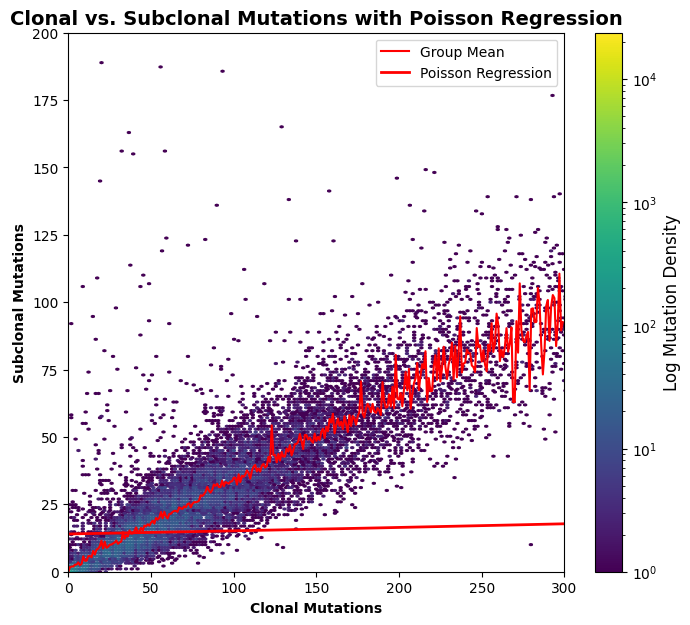

In [14]:
import matplotlib.pyplot as plt
import numpy as np
import statsmodels.api as sm  # Ensure statsmodels is imported
import statsmodels.api as sm

# Define the predictor and response variables
x = clonal_summary_binom["Clonal Count"]
y = clonal_summary_binom["Sub-Clonal Count"]
# Add a constant to the predictor variable (intercept term)
x_with_const = sm.add_constant(x)

# Fit the Poisson regression model
poisson_model = sm.GLM(y, x_with_const, family=sm.families.Poisson()).fit()

# Print the summary of the model
print(poisson_model.summary())

# calculate the mean of the response variable by the predictor variable
group_means = []
xlim = 300
step = 1
for i in range(0, xlim, step):
    group_means.append(clonal_summary_binom[(x >= i) & (x < i + step)]["Sub-Clonal Count"].mean())

# Generate values for prediction
step = 1  # Step size for x-axis
xlim = 300  # Limit for x-axis
ylim = 200  # Limit for y-axis
x_plot = np.arange(0, xlim)  # Generate 400 values between 0 and 400
x_step = np.arange(0, xlim, step)  # Generate values in steps of 1

# Create a design matrix for prediction (add an intercept)
x_pred = sm.add_constant(x_plot)  # Ensures it matches the Poisson model structure

# Predict the Sub-Clonal Count using the Poisson regression model
predicted_counts = poisson_model.predict(x_pred)  # Use the corrected matrix

# Create the Hexbin Plot (R-style)
fig, ax = plt.subplots(figsize=(8, 7))
hb = ax.hexbin(
    x, y, 
    gridsize=5000, cmap="viridis", bins='log' ,mincnt=1  # Use log scale for density
)

# Add the Group Means
ax.plot(x_step, group_means[0:xlim//step], color="red",  label="Group Mean")

# Add the Poisson Regression Line
ax.plot(x_plot, predicted_counts, color="red", linestyle="-", linewidth=2, label="Poisson Regression")

# Improve Labels and Title (ggplot2-like styling)
ax.set_xlim([0, xlim])  # Adjust these values based on your data
ax.set_ylim([0, ylim])  # Adjust these values based on your data
ax.set_xlabel("Clonal Mutations", fontsize=10, fontweight="bold")
ax.set_ylabel("Subclonal Mutations", fontsize=10, fontweight="bold")
ax.set_title("Clonal vs. Subclonal Mutations with Poisson Regression", fontsize=14, fontweight="bold")

# Add a Colorbar for Density
cb = fig.colorbar(hb, ax=ax)
cb.set_label("Log Mutation Density", fontsize=12)

ax.legend()  # Show the legend

# Show the Plot
plt.show()

                 Generalized Linear Model Regression Results                  
Dep. Variable:       Sub-Clonal Count   No. Observations:                44269
Model:                            GLM   Df Residuals:                    44267
Model Family:                 Poisson   Df Model:                            1
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:            -7.9469e+05
Date:                Fri, 02 May 2025   Deviance:                   1.4899e+06
Time:                        17:38:09   Pearson chi2:                 1.94e+06
No. Iterations:                    12   Pseudo R-squ. (CS):             0.9844
Covariance Type:            nonrobust                                         
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
const            2.7009      0.001   2219.577   

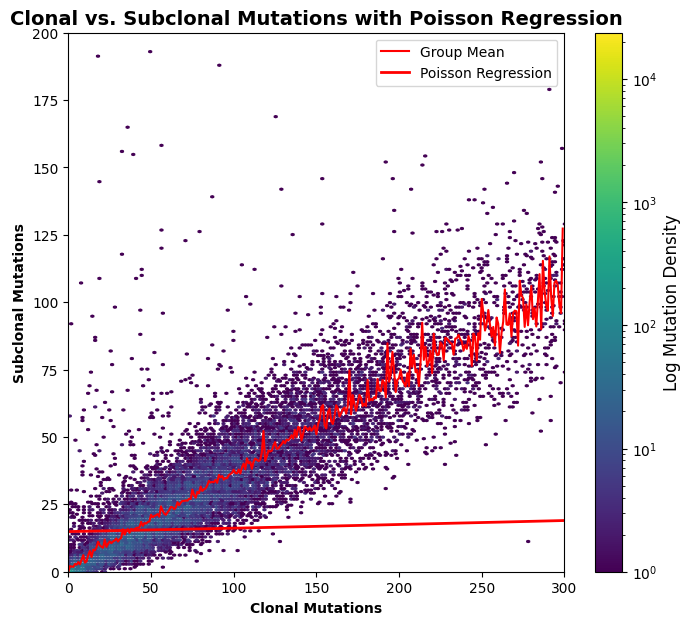

In [15]:
import matplotlib.pyplot as plt
import numpy as np
import statsmodels.api as sm  # Ensure statsmodels is imported

# Define the predictor and response variables
x = clonal_summary_Ztest["Clonal Count"]
y = clonal_summary_Ztest["Sub-Clonal Count"]
# Add a constant to the predictor variable (intercept term)
x_with_const = sm.add_constant(x)

# Fit the Poisson regression model
poisson_model = sm.GLM(y, x_with_const, family=sm.families.Poisson()).fit()

# Print the summary of the model
print(poisson_model.summary())

# calculate the mean of the response variable by the predictor variable
group_means = []
xlim = 300
step = 1
for i in range(0, xlim, step):
    group_means.append(clonal_summary_Ztest[(x >= i) & (x < i + step)]["Sub-Clonal Count"].mean())

# Generate values for prediction
step = 1  # Step size for x-axis
xlim = 300  # Limit for x-axis
ylim = 200  # Limit for y-axis
x_plot = np.arange(0, xlim)  # Generate 400 values between 0 and 400
x_step = np.arange(0, xlim, step)  # Generate values in steps of 1

# Create a design matrix for prediction (add an intercept)
x_pred = sm.add_constant(x_plot)  # Ensures it matches the Poisson model structure

# Predict the Sub-Clonal Count using the Poisson regression model
predicted_counts = poisson_model.predict(x_pred)  # Use the corrected matrix

# Create the Hexbin Plot (R-style)
fig, ax = plt.subplots(figsize=(8, 7))
hb = ax.hexbin(
    x, y, 
    gridsize=5000, cmap="viridis", bins='log' ,mincnt=1  # Use log scale for density
)

# Add the Group Means
ax.plot(x_step, group_means[0:xlim//step], color="red",  label="Group Mean")

# Add the Poisson Regression Line
ax.plot(x_plot, predicted_counts, color="red", linestyle="-", linewidth=2, label="Poisson Regression")

# Improve Labels and Title (ggplot2-like styling)
ax.set_xlim([0, xlim])  # Adjust these values based on your data
ax.set_ylim([0, ylim])  # Adjust these values based on your data
ax.set_xlabel("Clonal Mutations", fontsize=10, fontweight="bold")
ax.set_ylabel("Subclonal Mutations", fontsize=10, fontweight="bold")
ax.set_title("Clonal vs. Subclonal Mutations with Poisson Regression", fontsize=14, fontweight="bold")

# Add a Colorbar for Density
cb = fig.colorbar(hb, ax=ax)
cb.set_label("Log Mutation Density", fontsize=12)

ax.legend()  # Show the legend

# Show the Plot
plt.show()

## Negative binomial regression

Since the data are over dispersed, we should use a negative binomial regression instead

Optimization terminated successfully.
         Current function value: 2.601146
         Iterations: 16
         Function evaluations: 24
         Gradient evaluations: 19
                     NegativeBinomial Regression Results                      
Dep. Variable:       Sub-Clonal Count   No. Observations:                44269
Model:               NegativeBinomial   Df Residuals:                    44267
Method:                           MLE   Df Model:                            1
Date:                Fri, 02 May 2025   Pseudo R-squ.:                 0.08398
Time:                        17:38:16   Log-Likelihood:            -1.1515e+05
converged:                       True   LL-Null:                   -1.2571e+05
Covariance Type:            nonrobust   LLR p-value:                     0.000
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
const            0.1214      0.015

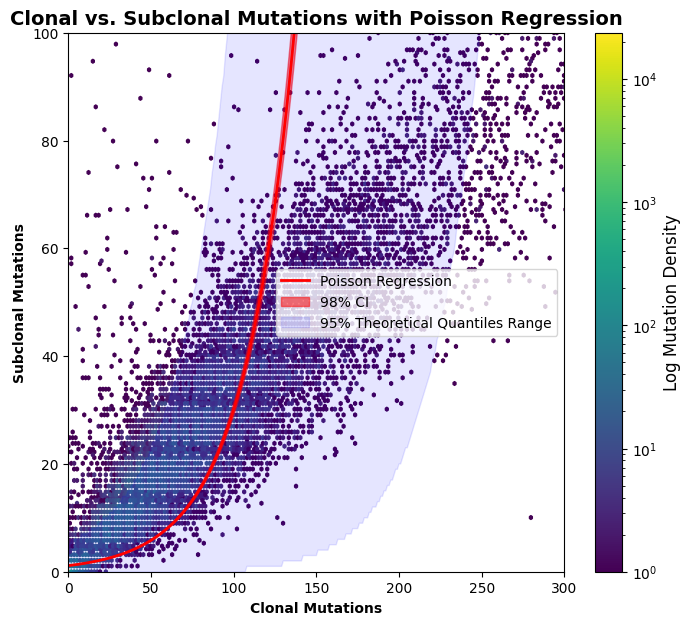

In [16]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import statsmodels.api as sm  # Ensure statsmodels is imported
from scipy.stats import nbinom  # Import nbinom for Negative Binomial distribution
import warnings

warnings.filterwarnings("ignore")  # Suppress all warnings

# Function to calculate quantiles for Negative Binomial distribution
def nb_quantiles(Y_pred: pd.Series, scale: float ,q_range=0.95):
    """
    Compute (1 - alpha)% quantile interval of a negative binomial 
    given predicted means (mu) and dispersion alpha.

    Parameters:
    - Y_pred: pd.Series of predicted means (μ values)
    - scale: dispersion parameter (α), where Var(Y) = μ + αμ²
    - alpha: float, defines the range for quantiles (default is 0.05 for 95% CI)

    Returns:
    - pd.DataFrame with lower and upper quantiles
    """
    theta = 1 / scale  # Dispersion parameter for Negative Binomial
    alpha = 1 - q_range  # Convert to alpha for quantiles
    p = theta / (theta + Y_pred)
    lower = nbinom.ppf(alpha / 2, theta, p)
    upper = nbinom.ppf(1 - alpha / 2, theta, p)
    return lower, upper

# Define the predictor and response variables
x = clonal_summary_binom["Clonal Count"]
y = clonal_summary_binom["Sub-Clonal Count"]
alpha = 0.02  # Significance level for confidence intervals

# Add a constant to the predictor variable (intercept term)
x_with_const = sm.add_constant(x)

# Fit the Negative Binomial regression model
nbinomial_model = sm.NegativeBinomial(y, x_with_const).fit()

# Get prediction results including confidence intervals
pred_results = nbinomial_model.get_prediction(x_pred)

# Extract confidence intervals
conf_int = pred_results.conf_int(alpha=alpha)  # Returns a (n, 2) array: lower and upper bounds

# Split the confidence intervals into lower and upper for plotting
lower_bound_bootstrap = conf_int[:, 0]
upper_bound_bootstrap = conf_int[:, 1]

# Print the summary of the model
print(nbinomial_model.summary())

# Generate values for prediction
xlim = 300  # Limit for x-axis
ylim = 100  # Limit for y-axis
x_plot = np.arange(0, xlim)  # Generate 400 values between 0 and 400

# Create a design matrix for prediction (add an intercept)
x_pred = sm.add_constant(x_plot)  # Ensures it matches the Poisson model structure

# Predict the Sub-Clonal Count using the Poisson regression model
predicted_counts = nbinomial_model.predict(x_pred)  # Use the corrected matrix

# Calculate the quantiles for the predicted counts
# Note: The scale parameter is the dispersion parameter for the Negative Binomial distribution
q_range = 0.95 # Range for quantiles (0.5 for median, 0.025 and 0.975 for 95% CI)
lower_quantile, upper_quantile = nb_quantiles(predicted_counts, scale=nbinomial_model.scale, q_range=q_range)

# Create the Hexbin Plot (R-style)
fig, ax = plt.subplots(figsize=(8, 7))
hb = ax.hexbin(
    x, y, 
    gridsize=5000, cmap="viridis", bins='log' ,mincnt=1  # Use log scale for density
)

# Add the Poisson Regression Line
ax.plot(x_plot, predicted_counts, color="red", linestyle="-", linewidth=2, label="Poisson Regression")

# Add bootstrap confidence interval as shaded area
ax.fill_between(x_plot, lower_bound_bootstrap, upper_bound_bootstrap, color="red", alpha=0.5, label=f"{(1-alpha)*100 :.0f}% CI")

# Add quantile intervals 
ax.fill_between(x_plot, lower_quantile, upper_quantile, color="blue", alpha=0.1, label=f"{q_range*100 :.0f}% Theoretical Quantiles Range")

# Improve Labels and Title (ggplot2-like styling)
ax.set_xlim([0, xlim])  # Adjust these values based on your data
ax.set_ylim([0, ylim])  # Adjust these values based on your data
ax.set_xlabel("Clonal Mutations", fontsize=10, fontweight="bold")
ax.set_ylabel("Subclonal Mutations", fontsize=10, fontweight="bold")
ax.set_title("Clonal vs. Subclonal Mutations with Poisson Regression", fontsize=14, fontweight="bold")

# Add a Colorbar for Density
cb = fig.colorbar(hb, ax=ax)
cb.set_label("Log Mutation Density", fontsize=12)

ax.legend()  # Show the legend

# Show the Plot
plt.show()

Optimization terminated successfully.
         Current function value: 2.639567
         Iterations: 16
         Function evaluations: 24
         Gradient evaluations: 19
                     NegativeBinomial Regression Results                      
Dep. Variable:       Sub-Clonal Count   No. Observations:                44269
Model:               NegativeBinomial   Df Residuals:                    44267
Method:                           MLE   Df Model:                            1
Date:                Fri, 02 May 2025   Pseudo R-squ.:                 0.08205
Time:                        17:38:36   Log-Likelihood:            -1.1685e+05
converged:                       True   LL-Null:                   -1.2730e+05
Covariance Type:            nonrobust   LLR p-value:                     0.000
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
const            0.1655      0.015

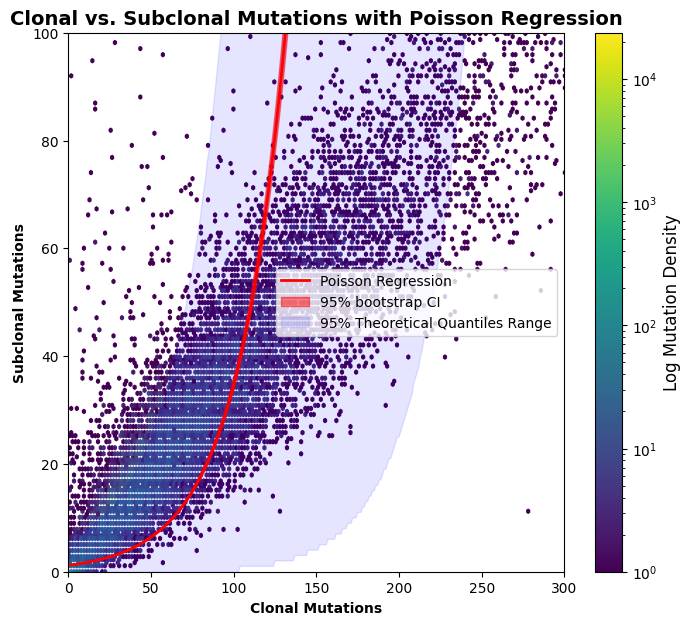

In [17]:
import matplotlib.pyplot as plt
import numpy as np
import statsmodels.api as sm  # Ensure statsmodels is imported
import statsmodels.api as sm
import warnings

warnings.filterwarnings("ignore")  # Suppress all warnings

# Function to calculate quantiles for Negative Binomial distribution
def nb_quantiles(Y_pred: pd.Series, scale: float ,q_range=0.95):
    """
    Compute (1 - alpha)% quantile interval of a negative binomial 
    given predicted means (mu) and dispersion alpha.

    Parameters:
    - Y_pred: pd.Series of predicted means (μ values)
    - scale: dispersion parameter (α), where Var(Y) = μ + αμ²
    - alpha: float, defines the range for quantiles (default is 0.05 for 95% CI)

    Returns:
    - pd.DataFrame with lower and upper quantiles
    """
    theta = 1 / scale  # Dispersion parameter for Negative Binomial
    alpha = 1 - q_range  # Convert to alpha for quantiles
    p = theta / (theta + Y_pred)
    lower = nbinom.ppf(alpha / 2, theta, p)
    upper = nbinom.ppf(1 - alpha / 2, theta, p)
    return lower, upper

# Define the predictor and response variables
x = clonal_summary_Ztest["Clonal Count"]
y = clonal_summary_Ztest["Sub-Clonal Count"]
alpha = 0.05  # Significance level for confidence intervals

# Add a constant to the predictor variable (intercept term)
x_with_const = sm.add_constant(x)

# Fit the Poisson regression model
nbinomial_model = sm.NegativeBinomial(y, x_with_const).fit()

# Get prediction results including confidence intervals
pred_results = nbinomial_model.get_prediction(x_pred)

# Extract confidence intervals
conf_int = pred_results.conf_int(alpha=alpha)  # Returns a (n, 2) array: lower and upper bounds

# Split the confidence intervals into lower and upper for plotting
lower_bound = conf_int[:, 0]
upper_bound = conf_int[:, 1]

# Print the summary of the model
print(nbinomial_model.summary())

# Generate values for prediction
xlim = 300  # Limit for x-axis
ylim = 100  # Limit for y-axis
x_plot = np.arange(0, xlim)  # Generate 400 values between 0 and 400

# Create a design matrix for prediction (add an intercept)
x_pred = sm.add_constant(x_plot)  # Ensures it matches the Poisson model structure

# Predict the Sub-Clonal Count using the Poisson regression model
predicted_counts = nbinomial_model.predict(x_pred)  # Use the corrected matrix

# Calculate the quantiles for the predicted counts
# Note: The scale parameter is the dispersion parameter for the Negative Binomial distribution
q_range = 0.95  # Range for quantiles (0.5 for median, 0.025 and 0.975 for 95% CI)
lower_quantile, upper_quantile = nb_quantiles(predicted_counts, scale=nbinomial_model.scale, q_range=q_range)

# Create the Hexbin Plot (R-style)
fig, ax = plt.subplots(figsize=(8, 7))
hb = ax.hexbin(
    x, y, 
    gridsize=5000, cmap="viridis", bins='log' ,mincnt=1  # Use log scale for density
)

# Add the Poisson Regression Line
ax.plot(x_plot, predicted_counts, color="red", linestyle="-", linewidth=2, label="Poisson Regression")

# Add confidence interval as shaded area
ax.fill_between(x_plot, lower_bound, upper_bound, color="red", alpha=0.5, label=f"{(1-alpha)*100 :.0f}% bootstrap CI")

# Add quantile intervals 
ax.fill_between(x_plot, lower_quantile, upper_quantile, color="blue", alpha=0.1, label=f"{(q_range)*100 :.0f}% Theoretical Quantiles Range")

# Improve Labels and Title (ggplot2-like styling)
ax.set_xlim([0, xlim])  # Adjust these values based on your data
ax.set_ylim([0, ylim])  # Adjust these values based on your data
ax.set_xlabel("Clonal Mutations", fontsize=10, fontweight="bold")
ax.set_ylabel("Subclonal Mutations", fontsize=10, fontweight="bold")
ax.set_title("Clonal vs. Subclonal Mutations with Poisson Regression", fontsize=14, fontweight="bold")

# Add a Colorbar for Density
cb = fig.colorbar(hb, ax=ax)
cb.set_label("Log Mutation Density", fontsize=12)

ax.legend()  # Show the legend

# Show the Plot
plt.show()

The visualizations below applies methods to filter out outliers for n-D scatter plots, there are not useful for this use case but could be useful later

---

## Appendix

To have a better visualization of regression relationship, I filtered out outliers using seperatly Interquantile Range and Z-Score. 

**IQR**
This method calculates 25th and 75th quantile then preserve only the data within this quantile for x and y 

**Z-Score**
$$ Z = \frac{X-\mu}{\sigma} $$ 
If $|Z| \leq 3$ then it's considered as an outlier. 


NO NEED to filter out the outliers for the regression

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from scipy.stats import linregress

# Set R-style theme (ggplot2-like styling)
sns.set_theme(style="whitegrid")  # Equivalent to ggplot2's `theme_minimal()`
plt.style.use("ggplot")  # Ensures a ggplot2-style background

# Compute IQR and Remove Outliers**
def iqr_filter(df, column):
    """Filter data based on IQR range for a given column."""
    Q1, Q3 = np.percentile(df[column], [25, 75])
    IQR = Q3 - Q1
    lower_bound, upper_bound = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    return df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]

# Apply IQR filtering on both Clonal and Sub-Clonal counts
filtered_data = iqr_filter(clonal_summary, "Clonal Count")
filtered_data = iqr_filter(filtered_data, "Sub-Clonal Count")

# Extract filtered data
x_filtered = filtered_data["Clonal Count"]
y_filtered = filtered_data["Sub-Clonal Count"]

# Fit a linear regression model to the filtered data
slope, intercept, r_value, p_value, std_err = linregress(x_filtered, y_filtered)

# Generate regression line
x_vals = np.linspace(min(x_filtered), max(x_filtered), 100)
y_vals = slope * x_vals + intercept

# Create the Hexbin Plot (R-style)
fig, ax = plt.subplots(figsize=(8, 7))
# sns.histplot(data=filtered_data, x="Clonal Count", y="Sub-Clonal Count", bins=100, ax=ax, cmap="viridis", cbar=True, cbar_kws={"label": "Density"})
hb = ax.hexbin(x_filtered, y_filtered, gridsize=200, cmap="viridis", bins="log", mincnt=1)  # Use log scale for density

# Add a Regression Line (ggplot2-like)
ax.plot(x_vals, y_vals, color="blue", linestyle="-", linewidth=2, label=f"Regression (y = {slope:.2f}x + {intercept:.2f})")

# # Add a Diagonal Reference Line (y = x)
# max_val = max(x_filtered.max(), y_filtered.max())
# ax.plot([0, max_val], [0, max_val], color="red", linestyle="dashed", linewidth=1)  # Similar to `geom_abline()`

# Improve Labels and Title (ggplot2-like styling)
ax.set_xlabel("Clonal Mutations", fontsize=10, fontweight="bold")
ax.set_ylabel("Subclonal Mutations", fontsize=10, fontweight="bold")
ax.set_title("Clonal vs. Subclonal Mutations (IQR Filtered)", fontsize=14, fontweight="bold")

# Add a Colorbar for Density (ggplot2-like)
cb = fig.colorbar(hb, ax=ax)
cb.set_label("Log Mutation Density", fontsize=12)

ax.legend()  # Show the legend
# Remove Unnecessary Spines (Cleaner ggplot2 style)
# sns.despine(left=True, bottom=True)

# Show the Plot
plt.show()

In [ ]:
from scipy.stats import zscore

# Compute Z-scores
z_scores = np.abs(zscore(clonal_summary[["Clonal Count", "Sub-Clonal Count"]]))

# Set threshold for outliers (e.g., 3 standard deviations)
filtered_data = clonal_summary[(z_scores < 3).all(axis=1)]

# Extract filtered data
x_filtered = filtered_data["Clonal Count"]
y_filtered = filtered_data["Sub-Clonal Count"]

# Fit a linear regression model to the filtered data
slope, intercept, r_value, p_value, std_err = linregress(x_filtered, y_filtered)

# Generate regression line
x_vals = np.linspace(min(x_filtered), max(x_filtered), 100)
y_vals = slope * x_vals + intercept

# Create the Hexbin Plot (R-style)
fig, ax = plt.subplots(figsize=(8, 7))
hb = ax.hexbin(x_filtered, y_filtered, gridsize=200, cmap="viridis", bins="log", mincnt=1)  # Use log scale for density

# Add a Regression Line (ggplot2-like)
ax.plot(x_vals, y_vals, color="blue", linestyle="-", linewidth=2, label=f"Regression (y = {slope:.2f}x + {intercept:.2f})")

# # Add a Diagonal Reference Line (y = x)
# max_val = max(x_filtered.max(), y_filtered.max())
# ax.plot([0, max_val], [0, max_val], color="red", linestyle="dashed", linewidth=1)  # Similar to `geom_abline()`

# Improve Labels and Title (ggplot2-like styling)
ax.set_xlabel("Clonal Mutations", fontsize=10, fontweight="bold")
ax.set_ylabel("Subclonal Mutations", fontsize=10, fontweight="bold")
ax.set_title("Clonal vs. Subclonal Mutations (Z-Score Filtered)", fontsize=14, fontweight="bold")

# Add a Colorbar for Density (ggplot2-like)
cb = fig.colorbar(hb, ax=ax)
cb.set_label("Log Mutation Density", fontsize=12)

ax.legend()  # Show the legend
# Remove Unnecessary Spines (Cleaner ggplot2 style)
# sns.despine(left=True, bottom=True)

# Show the Plot
plt.show()

In [ ]:
# Extract filtered data
x = clonal_summary["Clonal Count"]
y = clonal_summary["Sub-Clonal Count"]

# Fit a linear regression model to the filtered data
slope, intercept, r_value, p_value, std_err = linregress(x, y)

# Generate regression line
x_vals = np.linspace(min(x), max(x), 100)
y_vals = slope * x_vals + intercept

# Create the Hexbin Plot (R-style)
fig, ax = plt.subplots(figsize=(8, 7))
hb = ax.hexbin(x, y, gridsize=300, cmap="viridis", bins="log", mincnt=1)  # Use log scale for density

# Add a Regression Line (ggplot2-like)
ax.plot(x_vals, y_vals, color="blue", linestyle="-", linewidth=2, label=f"Regression (y = {slope:.2f}x + {intercept:.2f})")

# # Add a Diagonal Reference Line (y = x)
# max_val = max(x_filtered.max(), y_filtered.max())
# ax.plot([0, max_val], [0, max_val], color="red", linestyle="dashed", linewidth=1)  # Similar to `geom_abline()`

# Improve Labels and Title (ggplot2-like styling)
ax.set_xlabel("Clonal Mutations", fontsize=10, fontweight="bold")
ax.set_ylabel("Subclonal Mutations", fontsize=10, fontweight="bold")
ax.set_title("Clonal vs. Subclonal Mutations (Not Filtered)", fontsize=14, fontweight="bold")

# Add a Colorbar for Density (ggplot2-like)
cb = fig.colorbar(hb, ax=ax)
cb.set_label("Log Mutation Density", fontsize=12)

ax.legend()  # Show the legend
# Remove Unnecessary Spines (Cleaner ggplot2 style)
# sns.despine(left=True, bottom=True)

# Show the Plot
plt.show()

Do Poisson tests to the data frame clonal summary